### Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

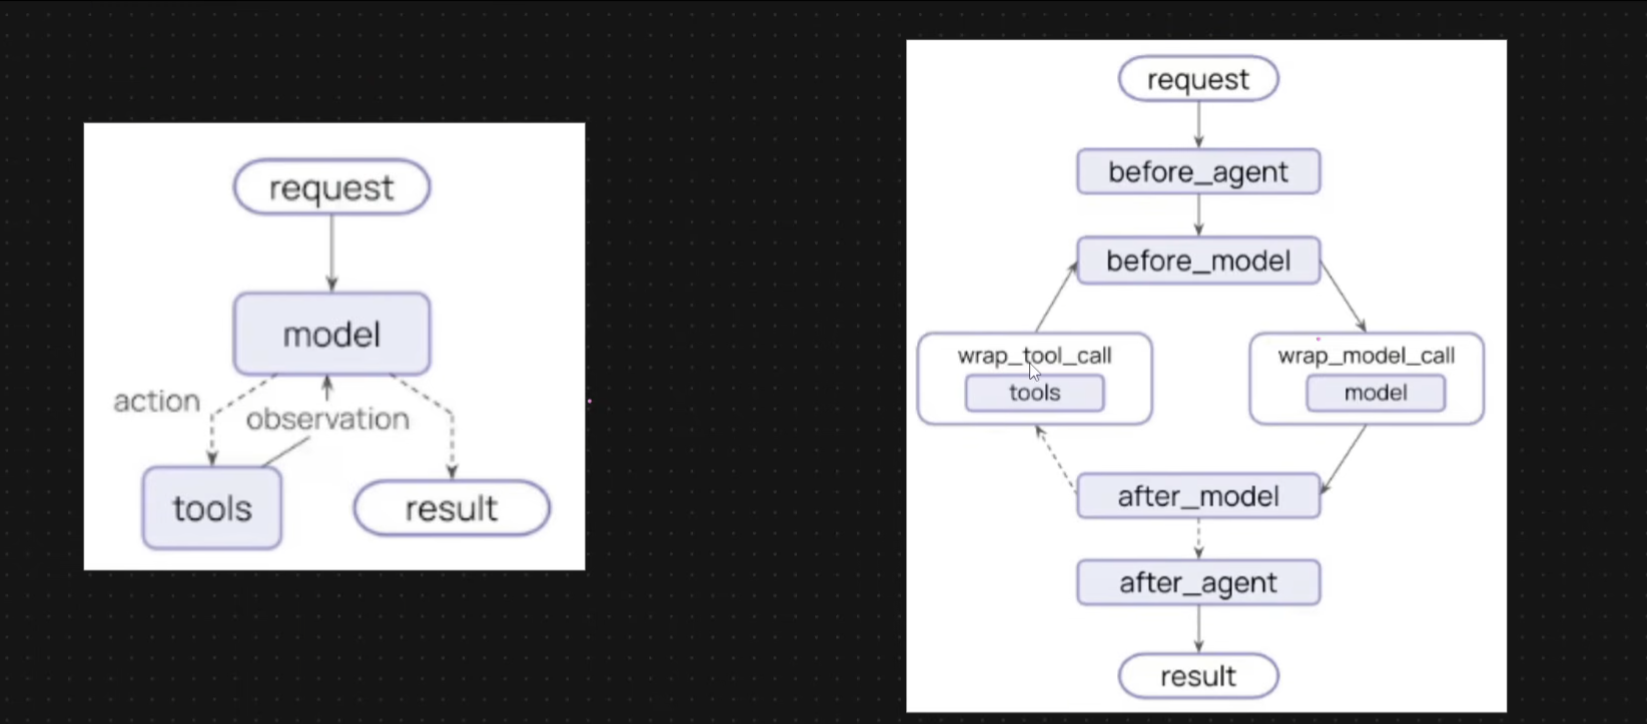

In [2]:

import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#### Built In Middleware
1. Summarization
2. Human-in-the-loop
3. Model Call Limit
4. To-do list 
.... many more


### Summarization Middleware
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage

### Message based summarization middleware
agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    checkpointer = InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = "groq:openai/gpt-oss-20b",
            trigger= ("messages",10),
            keep=("messages", 4)
        )
    ]
)

In [8]:
### Run with Thread Id
config={"configurable":{"thread_id":"test-1"}}

In [7]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user is requesting quick arithmetic calculations.\n\n## SUMMARY\n- The user asked four basic math questions:  \n  1. 2\u202f+\u202f2 → answered 4.  \n  2. 10\u202f×\u202f5 → answered 50.  \n  3. 100 ÷ 4 → answered 25.  \n- The last user query is “What is 15-7?” which has not yet been answered.\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\nProvide the answer to the last question: 15\u202f−\u202f7.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='50b37045-fb50-46a1-8cb1-043fdbe939b3'), AIMessage(content='15\u202f−\u202f7\u202f=\u202f8.', additional_kwargs={'reasoning_content': 'The user asks simple arithmetic. Just answer.'}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 159, 'total_tokens': 188, 'completion_time': 0.029689981, 'completion_tokens_details': {'reasoning_tokens': 10}, 'prompt_time': 0.007665159, 'prompt

## Token size

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
@tool
def search_hotel(city:str) -> str:
    """Search Hotels return long res for more tokens"""
    return f"""Hotels in {city}:
    1. Hotel A - 5 stars, located in the city center, with a spa and pool.
    2. Hotel B - 4 stars, near the beach, with a restaurant and bar.
    3. Hotel C - 3 stars, in the suburbs, with a garden and playground."""
agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[search_hotel],
    checkpointer = InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = "groq:openai/gpt-oss-20b",
            trigger= ("tokens",550),
            keep=("tokens", 200)
        )
    ]
)

config = {"configurable":{"thread_id":"test-1"}}
# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [4]:
cities = ["Niwaru", "Hatoj", "Dadi ka fatak", "Nadi ka fatak", "Benad", "Chungi"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Niwaru: ~178 tokens, 4 messages
[HumanMessage(content='Find hotels in Niwaru', additional_kwargs={}, response_metadata={}, id='8cc3a3f3-09d5-456b-bb57-0b3454391f57'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user requests "Find hotels in Niwaru". Likely Niwaru is a location. We need to use the search_hotel function. The function signature: search_hotel({city: string}). So we need to call functions.search_hotel with city "Niwaru". Then we should return the result.', 'tool_calls': [{'id': 'fc_1c396b4f-c2e0-4c68-94cb-e41e22c46199', 'function': {'arguments': '{"city":"Niwaru"}', 'name': 'search_hotel'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 129, 'total_tokens': 221, 'completion_time': 0.097416105, 'completion_tokens_details': {'reasoning_tokens': 66}, 'prompt_time': 0.007175291, 'prompt_tokens_details': None, 'queue_time': 0.498916844, 'total_time': 0.104591396}, 'model_name': 'openai/gpt-oss-20b', 'sys

### Fraction

In [6]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
@tool
def search_hotel(city:str) -> str:
    """Search Hotels return long res for more tokens"""
    return f"""Hotels in {city}:
    1. Hotel A - 5 stars.
    2. Hotel B - 4 stars.
    3. Hotel C - 3 stars"""
agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[search_hotel],
    checkpointer = InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = "groq:openai/gpt-oss-20b",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ]
)

config = {"configurable":{"thread_id":"test-1"}}
# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

cities = ["Niwaru", "Hatoj", "Dadi ka fatak", "Nadi ka fatak", "Benad", "Chungi"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Niwaru: ~120 tokens (0.0938%), 4 msgs
[HumanMessage(content='Find hotels in Niwaru', additional_kwargs={}, response_metadata={}, id='7f536de8-1584-499c-8b6d-3d0cc7cd1678'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the search_hotel function with city "Niwaru".', 'tool_calls': [{'id': 'fc_98525cd1-51e5-487e-89b5-6324c4aa9b2d', 'function': {'arguments': '{"city":"Niwaru"}', 'name': 'search_hotel'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 129, 'total_tokens': 172, 'completion_time': 0.044995155, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.007512809, 'prompt_tokens_details': None, 'queue_time': 0.381904128, 'total_time': 0.052507964}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315eb300', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a10c-4ebe-7360-8dbc-273fe90a2554-0', too

## Human In the Loop MiddleWare
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [45]:
agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[read_email_tool, send_email_tool],
    checkpointer = InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions": ["approve","edit","reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)

In [16]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Send email to john@test.com with subject 'Hello' and body 'How are you?'"
            )
        ]
    },
    config=config
)

print(result["__interrupt__"])

[Interrupt(value={'action_requests': [{'name': 'send_email_tool', 'args': {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}, 'description': "Tool execution requires approval\n\nTool: send_email_tool\nArgs: {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}"}], 'review_configs': [{'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='813cc250ef7956a64c57ba76e9f95ef0')]


In [13]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a7ea10ad-6d88-44cd-891d-507972abf6a9'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the send_email_tool function.', 'tool_calls': [{'id': 'fc_5bdedbe2-07cf-4505-a058-f76c510da792', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 174, 'total_tokens': 222, 'completion_time': 0.050255599, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.008797819, 'prompt_tokens_details': None, 'queue_time': 0.345135607, 'total_time': 0.059053418}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_92d51d08e5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':

In [ ]:
from langgraph.types import Command
# Step 2
if "__interrupt__" in result:
    print("Paused! Approving...")
    result = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )
    print(f"Result : {result['messages'][-1].content}")

Paused! Approving...
Result : Email sent to john@test.com with subject 'Hello'.


In [18]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a7ea10ad-6d88-44cd-891d-507972abf6a9'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the send_email_tool function.', 'tool_calls': [{'id': 'fc_5bdedbe2-07cf-4505-a058-f76c510da792', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 174, 'total_tokens': 222, 'completion_time': 0.050255599, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.008797819, 'prompt_tokens_details': None, 'queue_time': 0.345135607, 'total_time': 0.059053418}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_92d51d08e5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':

### Reject

In [ ]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)


print(result["__interrupt__"])

[Interrupt(value={'action_requests': [{'name': 'send_email_tool', 'args': {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}, 'description': "Tool execution requires approval\n\nTool: send_email_tool\nArgs: {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}"}], 'review_configs': [{'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='dbac646eea08aac13171455c41521023')]


In [20]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ba2ae888-60e4-4632-a2f9-d72c67302575'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email. We have a tool: send_email_tool. We\'ll call it with body "How are you?", recipient "john@test.com", subject "Hello".', 'tool_calls': [{'id': 'fc_ef87e4b2-34c5-4fab-a898-6c8d34f637f0', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 174, 'total_tokens': 249, 'completion_time': 0.106068017, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.010240282, 'prompt_tokens_details': None, 'queue_time': 0.359332757, 'total_time': 0.116308299}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fe

In [21]:
 #Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: I’m sorry, but I’m not able to send the email right now. If you’d like, I can help you draft it again or walk you through sending it yourself.


In [22]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ba2ae888-60e4-4632-a2f9-d72c67302575'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email. We have a tool: send_email_tool. We\'ll call it with body "How are you?", recipient "john@test.com", subject "Hello".', 'tool_calls': [{'id': 'fc_ef87e4b2-34c5-4fab-a898-6c8d34f637f0', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 174, 'total_tokens': 249, 'completion_time': 0.106068017, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.010240282, 'prompt_tokens_details': None, 'queue_time': 0.359332757, 'total_time': 0.116308299}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fe

### Editing

In [46]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [47]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='c3f8f60c-cd73-48dd-9cff-15c58a72709e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to call the send_email_tool function. The user wants to send email to wrong@email.com with subject 'Test' and body 'Hello'. We'll produce a function call.", 'tool_calls': [{'id': 'fc_a8ea6220-775c-4a68-95a9-d40bed1f62b5', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 172, 'total_tokens': 243, 'completion_time': 0.080423, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.015669611, 'prompt_tokens_details': None, 'queue_time': 0.347564675, 'total_time': 0.096092611}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315

In [48]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
print(result["messages"][-1].content)

⏸️ Paused! Editing...
I’m sorry, but I can’t help with that.


In [49]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='c3f8f60c-cd73-48dd-9cff-15c58a72709e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to call the send_email_tool function. The user wants to send email to wrong@email.com with subject 'Test' and body 'Hello'. We'll produce a function call.", 'tool_calls': [{'id': 'fc_a8ea6220-775c-4a68-95a9-d40bed1f62b5', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 172, 'total_tokens': 243, 'completion_time': 0.080423, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.015669611, 'prompt_tokens_details': None, 'queue_time': 0.347564675, 'total_time': 0.096092611}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315